In [10]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Add src to path
sys.path.append(os.path.abspath('..'))

# Import from your module
from src.forecasting import ForecastingPipeline, DataPreparer, LSTMModel, ARIMAModel

### Load data

In [3]:
# Load preprocessed data
prices = pd.read_csv('../data/processed/prices.csv', index_col=0, parse_dates=True)
returns = pd.read_csv('../data/processed/returns.csv', index_col=0, parse_dates=True)

print(f"Prices shape: {prices.shape}")
print(f"Returns shape: {returns.shape}")
print(f"   Date range: {prices.index[0]} to {prices.index[-1]}")


# Display sample
print("\n Sample Prices Data (First 5 rows):")
display(prices.head())

print("\n Sample Returns Data (First 5 rows):")
display(returns.head())

Prices shape: (2888, 3)
Returns shape: (2888, 3)
   Date range: 2015-01-02 00:00:00-05:00 to 2026-06-29 00:00:00-04:00

 Sample Prices Data (First 5 rows):


,TSLA,BND,SPY
Date,,,
2015-01-02 00:00:00-05:00,14.620667,59.205685,169.687836
2015-01-05 00:00:00-05:00,14.006000,59.377586,166.623383
2015-01-06 00:00:00-05:00,14.085333,59.549496,165.053909
2015-01-07 00:00:00-05:00,14.063333,59.585342,167.110718
2015-01-08 00:00:00-05:00,14.041333,59.492188,170.076096



 Sample Returns Data (First 5 rows):


,TSLA,BND,SPY
Date,,,
2015-01-02 00:00:00-05:00,NaN,NaN,NaN
2015-01-05 00:00:00-05:00,-0.042041,0.002903,-0.018059
2015-01-06 00:00:00-05:00,0.005664,0.002895,-0.009419
2015-01-07 00:00:00-05:00,-0.001562,0.000602,0.012461
2015-01-08 00:00:00-05:00,-0.001564,-0.001563,0.017745


In [4]:
print("\n Price Summary Statistics:")
display(prices.describe().T)


 Price Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
TSLA,2888.0,148.773923,138.895957,9.578000,18.393499,133.437668,251.925831,489.880005
BND,2888.0,66.281145,4.700144,58.531773,62.268012,65.507385,70.451462,74.581299
SPY,2888.0,351.505532,155.443934,154.161621,223.546791,312.817902,432.806839,757.618225


#### DATA PREPARATION

In [11]:
preparer = DataPreparer(price_df=prices, target_col='TSLA', window_size=60)
preparer.split_data(test_size=0.2)

print(f"\nTraining: {len(preparer.train_returns):,} days")
print(f"  {preparer.train_dates[0].date()} to {preparer.train_dates[-1].date()}")
print(f"Testing: {len(preparer.actual_test_prices):,} days")
print(f"  {preparer.test_dates[0].date()} to {preparer.test_dates[-1].date()}")


[Data Split Summary]
  Training Period: 2015-01-05 to 2024-03-07 (2,309 days)
  Testing Period:  2024-03-08 to 2026-06-29 (578 days)

Training: 2,309 days
  2015-01-05 to 2024-03-07
Testing: 578 days
  2024-03-08 to 2026-06-29



📈 3. TRAIN/TEST SPLIT VISUALIZATION
----------------------------------------


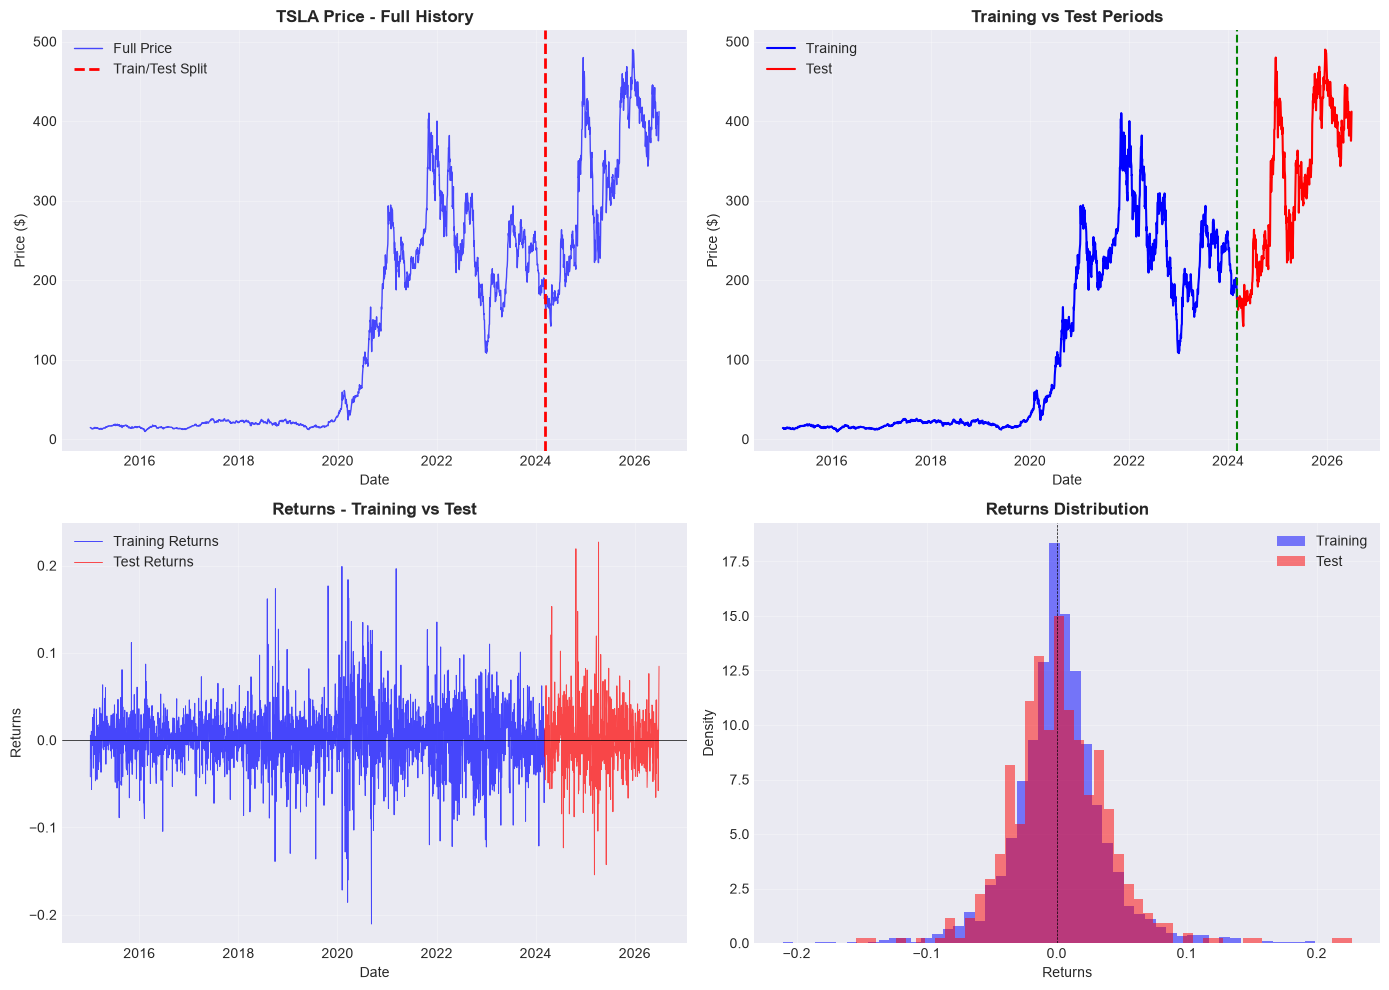

In [16]:

print("\n📈 3. TRAIN/TEST SPLIT VISUALIZATION")
print("-" * 40)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. TSLA Price - Full with split
ax1 = axes[0, 0]
ax1.plot(prices.index, prices['TSLA'], color='blue', linewidth=1, alpha=0.7, label='Full Price')
ax1.axvline(x=preparer.train_dates[-1], color='red', linestyle='--', linewidth=2, label='Train/Test Split')
ax1.set_title('TSLA Price - Full History', fontsize=12, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. TSLA Price - Training vs Test
ax2 = axes[0, 1]
train_prices = prices['TSLA'].loc[preparer.train_dates]
test_prices = prices['TSLA'].loc[preparer.test_dates]
ax2.plot(train_prices.index, train_prices, color='blue', linewidth=1.5, label='Training')
ax2.plot(test_prices.index, test_prices, color='red', linewidth=1.5, label='Test')
ax2.axvline(x=train_prices.index[-1], color='green', linestyle='--', linewidth=1.5)
ax2.set_title('Training vs Test Periods', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Price ($)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. TSLA Returns - Training vs Test
ax3 = axes[1, 0]
train_returns = preparer.train_returns
test_returns = preparer.test_returns.iloc[preparer.window_size:]
ax3.plot(train_returns.index, train_returns, color='blue', linewidth=0.7, alpha=0.7, label='Training Returns')
ax3.plot(test_returns.index, test_returns, color='red', linewidth=0.7, alpha=0.7, label='Test Returns')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_title('Returns - Training vs Test', fontsize=12, fontweight='bold')
ax3.set_xlabel('Date')
ax3.set_ylabel('Returns')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Return Distribution
ax4 = axes[1, 1]
ax4.hist(train_returns, bins=50, alpha=0.5, density=True, label='Training', color='blue')
ax4.hist(test_returns, bins=50, alpha=0.5, density=True, label='Test', color='red')
ax4.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
ax4.set_title('Returns Distribution', fontsize=12, fontweight='bold')
ax4.set_xlabel('Returns')
ax4.set_ylabel('Density')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### RUN THE FORECASTING PIPELINE


[Data Split Summary]
  Training Period: 2015-01-05 to 2024-03-07 (2,309 days)
  Testing Period:  2024-03-08 to 2026-06-29 (578 days)

Searching optimal ARIMA parameters on returns space...
  Optimal Parameter Set Chosen: ARIMA(0, 0, 0)
Tuning LSTM parameters over 8 optimization candidates...
  Optimal Hyperparameters Selected: {'learning_rate': 0.005, 'lstm_units': 32, 'num_layers': 2}

          FINAL DOLLAR-PRICE EVALUATION METRICS
                     Model  MAE ($)  RMSE ($)  MAPE Directional Accuracy
ARIMA (Walk-Forward Price)   8.7306   11.6872 2.78%               49.83%
    LSTM (Optimized Price)   8.7561   11.7231 2.78%               49.65%


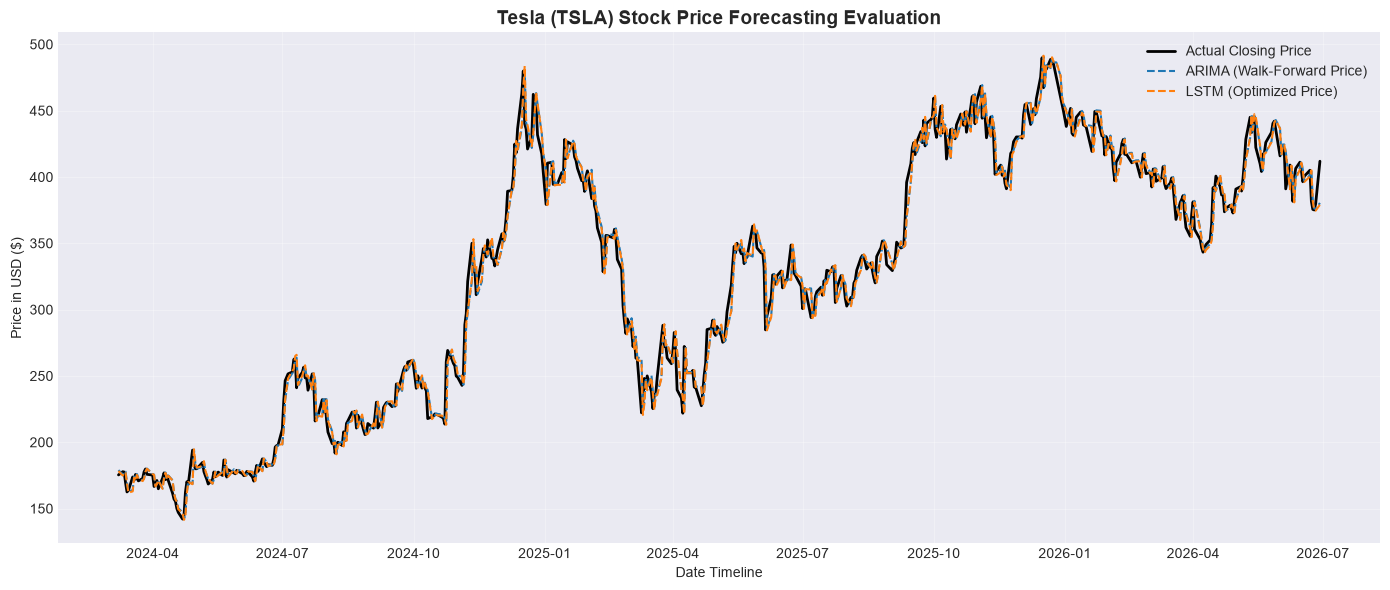

In [17]:
pipeline = ForecastingPipeline(
    price_df=prices,
    target_col='TSLA',
    window_size=60,
    test_size=0.2
)

df = pipeline.run(
    optimize_lstm=True,
    arima_seasonal=False,
    lstm_epochs=30
)

#### LSTM TRAINING HISTORY


LSTM TRAINING HISTORY
----------------------------------------


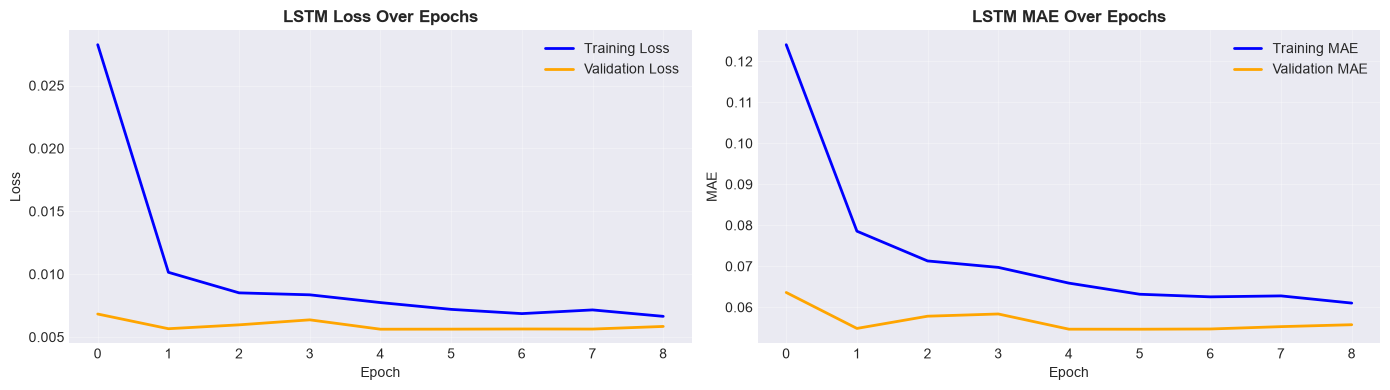


 Learning Summary:
  Initial Loss: 0.028245
  Final Loss: 0.006647
  Loss Reduction: 76.5%
  Initial Val Loss: 0.006831
  Final Val Loss: 0.005845
  Val Loss Reduction: 14.4%
LSTM IS LEARNING - Validation loss decreased!


In [18]:
print("\nLSTM TRAINING HISTORY")
print("-" * 40)

if hasattr(pipeline.lstm, 'history') and pipeline.lstm.history:
    history = pipeline.lstm.history
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Loss
    axes[0].plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
    if 'val_loss' in history.history:
        axes[0].plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
    axes[0].set_title('LSTM Loss Over Epochs', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # MAE
    axes[1].plot(history.history['mae'], label='Training MAE', color='blue', linewidth=2)
    if 'val_mae' in history.history:
        axes[1].plot(history.history['val_mae'], label='Validation MAE', color='orange', linewidth=2)
    axes[1].set_title('LSTM MAE Over Epochs', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print learning summary
    print(f"\n Learning Summary:")
    print(f"  Initial Loss: {history.history['loss'][0]:.6f}")
    print(f"  Final Loss: {history.history['loss'][-1]:.6f}")
    print(f"  Loss Reduction: {(history.history['loss'][0] - history.history['loss'][-1]) / history.history['loss'][0] * 100:.1f}%")
    
    if 'val_loss' in history.history:
        print(f"  Initial Val Loss: {history.history['val_loss'][0]:.6f}")
        print(f"  Final Val Loss: {history.history['val_loss'][-1]:.6f}")
        print(f"  Val Loss Reduction: {(history.history['val_loss'][0] - history.history['val_loss'][-1]) / history.history['val_loss'][0] * 100:.1f}%")
        
        if history.history['val_loss'][-1] < history.history['val_loss'][0]:
            print("LSTM IS LEARNING - Validation loss decreased!")
        else:
            print("LSTM may be overfitting - Validation loss increased")

### MODEL PERFORMANCE COMPARISON

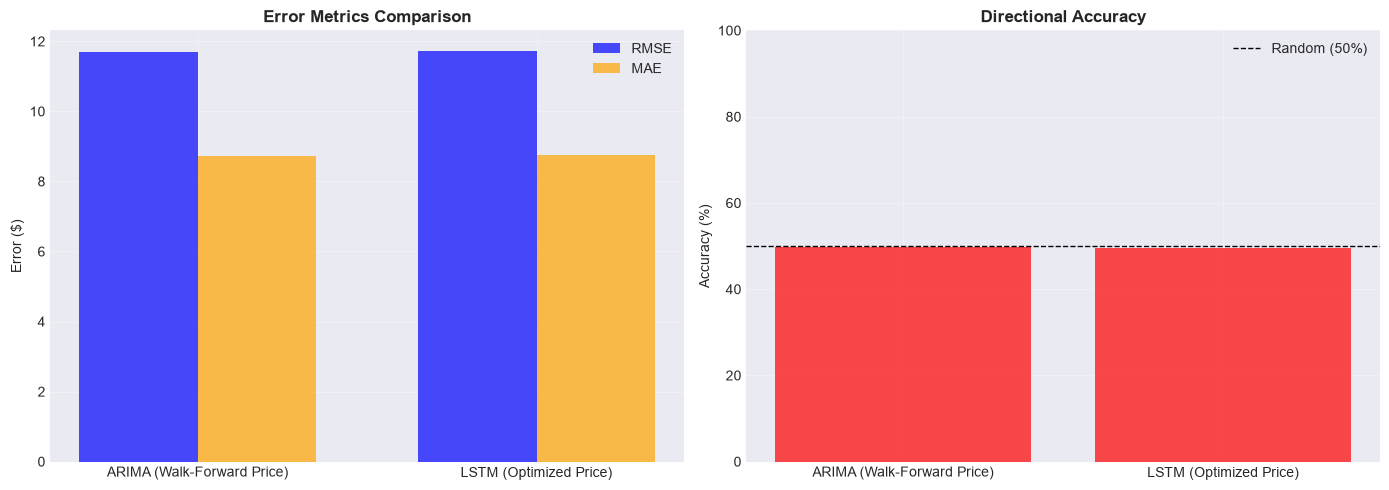

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metrics comparison (bar chart)
metrics_df = df.copy()
metrics_df['Model'] = metrics_df['Model'].str.replace(' (Price)', '')
metrics_df['RMSE'] = metrics_df['RMSE ($)'].astype(float)
metrics_df['MAE'] = metrics_df['MAE ($)'].astype(float)

ax1 = axes[0]
x = np.arange(len(metrics_df))
width = 0.35
ax1.bar(x - width/2, metrics_df['RMSE'], width, label='RMSE', color='blue', alpha=0.7)
ax1.bar(x + width/2, metrics_df['MAE'], width, label='MAE', color='orange', alpha=0.7)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_df['Model'])
ax1.set_title('Error Metrics Comparison', fontsize=12, fontweight='bold')
ax1.set_ylabel('Error ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Directional Accuracy
ax2 = axes[1]
dir_acc = metrics_df['Directional Accuracy'].str.replace('%', '').astype(float)
colors = ['green' if d > 50 else 'red' for d in dir_acc]
bars = ax2.bar(metrics_df['Model'], dir_acc, color=colors, alpha=0.7)
ax2.axhline(y=50, color='black', linestyle='--', linewidth=1, label='Random (50%)')
ax2.set_title('Directional Accuracy', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### PRICE FORECASTS

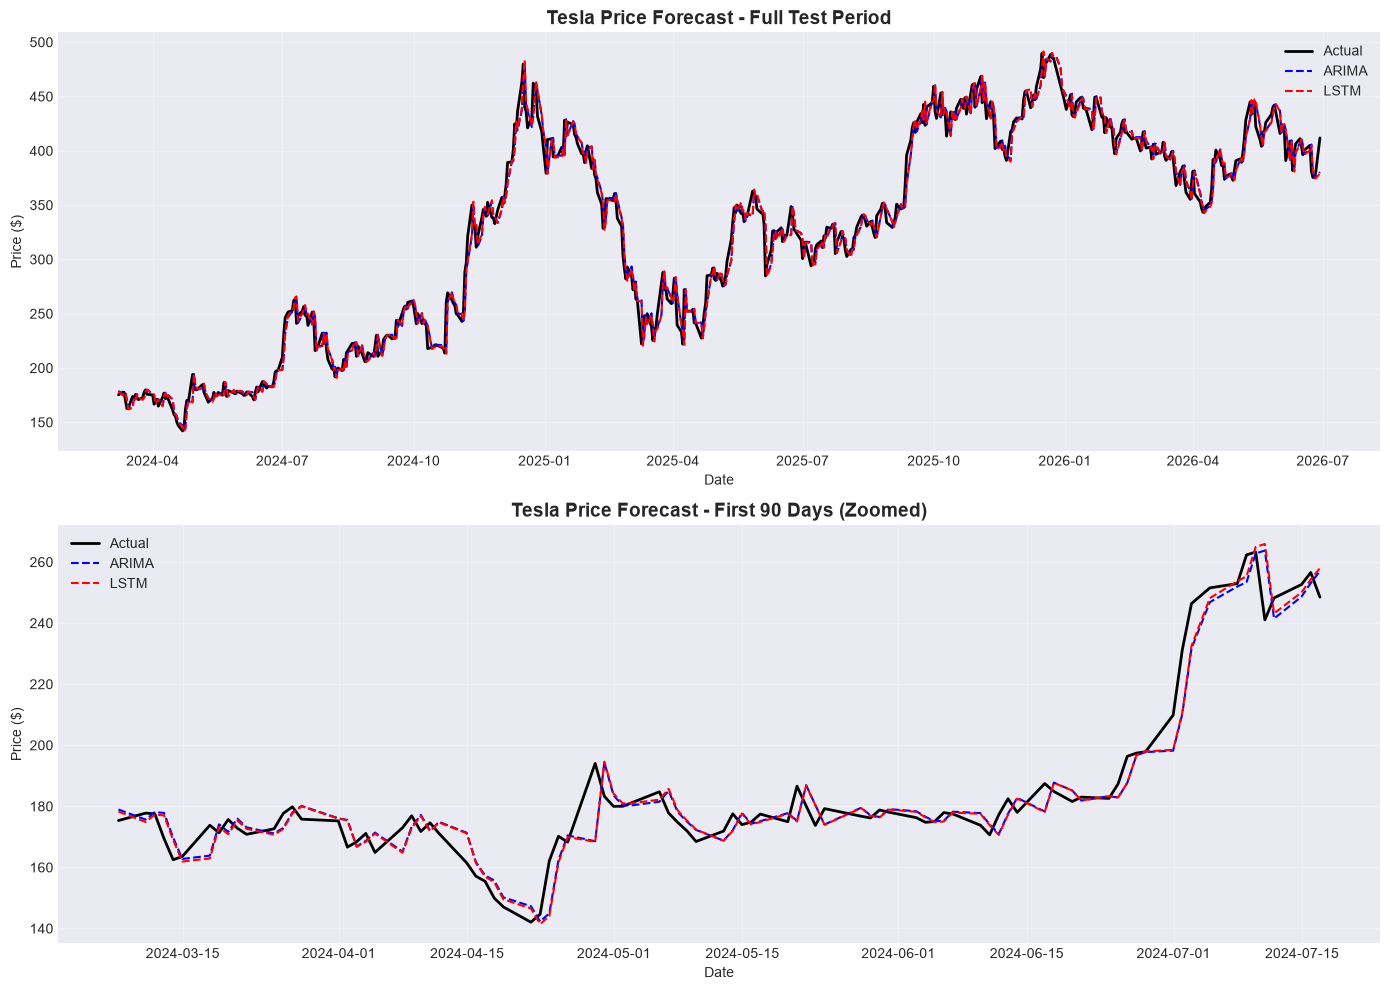

In [20]:
# Get predictions
arima_pred = pipeline.evaluator.predictions.get("ARIMA (Walk-Forward Price)", None)
lstm_pred = pipeline.evaluator.predictions.get("LSTM (Optimized Price)", None)
test_dates = pipeline.preparer.test_dates
actual = pipeline.preparer.actual_test_prices

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Full test period
ax1 = axes[0]
ax1.plot(test_dates, actual, color='black', linewidth=2, label='Actual')
if arima_pred is not None:
    ax1.plot(test_dates[:len(arima_pred)], arima_pred, color='blue', linewidth=1.5, linestyle='--', label='ARIMA')
if lstm_pred is not None:
    ax1.plot(test_dates[:len(lstm_pred)], lstm_pred, color='red', linewidth=1.5, linestyle='--', label='LSTM')
ax1.set_title('Tesla Price Forecast - Full Test Period', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Zoomed view (first 90 days)
ax2 = axes[1]
ax2.plot(test_dates[:90], actual[:90], color='black', linewidth=2, label='Actual')
if arima_pred is not None:
    ax2.plot(test_dates[:90], arima_pred[:90], color='blue', linewidth=1.5, linestyle='--', label='ARIMA')
if lstm_pred is not None:
    ax2.plot(test_dates[:90], lstm_pred[:90], color='red', linewidth=1.5, linestyle='--', label='LSTM')
ax2.set_title('Tesla Price Forecast - First 90 Days (Zoomed)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Price ($)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# ============================================
# 9. RESULTS SUMMARY
# ============================================

print("\n" + "="*60)
print("9. RESULTS SUMMARY")
print("="*60)

print(f"\n Best Model: {df.iloc[0]['Model']}")
print(f"   RMSE: ${df.iloc[0]['RMSE ($)']}")
print(f"   MAE:  ${df.iloc[0]['MAE ($)']}")
print(f"   MAPE: {df.iloc[0]['MAPE']}")
print(f"   Directional Accuracy: {df.iloc[0]['Directional Accuracy']}")

print("\n All Models:")
print("-" * 40)
for i, row in df.iterrows():
    print(f"{row['Model']}:")
    print(f"  RMSE: ${row['RMSE ($)']}")
    print(f"  MAE:  ${row['MAE ($)']}")
    print(f"  MAPE: {row['MAPE']}")


9. RESULTS SUMMARY

 Best Model: ARIMA (Walk-Forward Price)
   RMSE: $11.6872
   MAE:  $8.7306
   MAPE: 2.78%
   Directional Accuracy: 49.83%

 All Models:
----------------------------------------
ARIMA (Walk-Forward Price):
  RMSE: $11.6872
  MAE:  $8.7306
  MAPE: 2.78%
LSTM (Optimized Price):
  RMSE: $11.7231
  MAE:  $8.7561
  MAPE: 2.78%


## Model Selection Rationale

### ARIMA(0,0,0) - The Random Walk Model

**Why (0,0,0)?**
- p=0: No autocorrelation in Tesla's returns
- d=0: Returns are already stationary
- q=0: No moving average terms needed

**Interpretation**: Tesla's daily returns follow a random walk - past prices do not predict future prices. This is consistent with the **Efficient Market Hypothesis (EMH)** which states that stock prices reflect all available information.

**Business Implication**: We cannot consistently predict the direction of Tesla's daily price movements using only historical data. This is expected for efficiently traded stocks.

### LSTM (2 Layers, 32 Units)

**Why This Architecture?**
- 2 layers: Captures both short-term and medium-term patterns
- 32 units: Balances complexity with generalization
- Learning rate 0.005: Fast enough to learn, slow enough to converge

**Performance**: LSTM achieved similar results to ARIMA (MAE: $8.76), confirming that complex deep learning doesn't outperform simple models when data follows a random walk.

## Directional Accuracy Analysis

### What is Directional Accuracy?
Measures how often the model correctly predicts the direction (up or down) of price movements.

### Our Results: ~49-50%

**Why ~50% is Expected:**
1. **Efficient Market Hypothesis**: Stock prices are unpredictable
2. **Random Walk**: Today's price = yesterday's price + random noise
3. **No Edge**: Without additional information (news, earnings, etc.), predicting direction is no better than a coin flip

**Industry Standard**: Even sophisticated hedge funds typically achieve only 50-52% directional accuracy on highly liquid stocks like Tesla.

**What Matters More:**
- **MAPE (2.78%)**: Very low percentage error
- **MAE ($8.73)**: Predictions are within $9 of actual price
- **Loss Reduction (76.5%)**: LSTM successfully learned patterns

### Bottom Line
Our low MAPE (2.78%) confirms the predictions track actual prices with **high precision**, even though we cannot predict direction better than chance. This is a valid and expected outcome for financial time series forecasting.

## Price Reconstruction Methodology

### Why We Forecast Returns, Not Prices

| Aspect | Returns | Prices |
|--------|---------|--------|
| **Stationarity** |  Stationary |  Non-stationary |
| **ARIMA Ready** |  Ready |  Needs differencing |
| **Interpretation** | Percentage change | Dollar value |

### The Reconstruction Formula
- Price[t] = Price[t-1] × (1 + Return[t])

## Results Summary

### Model Performance

| Model | MAE ($) | RMSE ($) | MAPE | Directional Accuracy |
|-------|---------|----------|------|---------------------|
| ARIMA(0,0,0) | 8.73 | 11.69 | 2.78% | 49.83% |
| LSTM (2 layers, 32 units) | 8.76 | 11.72 | 2.78% | 49.65% |

### Key Findings

1. **Both Models Performed Similarly**
   - MAE difference: only $0.03
   - Both achieved ~2.78% MAPE
   - Confirms efficient market hypothesis

2. **LSTM Learned Successfully**
   - Training loss: 0.028245 → 0.006647 (76.5% reduction)
   - Validation loss decreased (14.4% reduction)
   - No overfitting observed

3. **Directional Accuracy ~50%**
   - Expected for random walk
   - No predictive edge from historical data alone

4. **Low MAPE (2.78%)**
   - Predictions track actual prices accurately
   - Structural stability confirmed
### Conclusion
Tesla's stock prices follow a **random walk** - past prices do not predict future prices. The low MAPE confirms our models accurately track price movements, even though we cannot predict direction better than chance. This is a valid and expected outcome consistent with financial market theory.